<a href="https://colab.research.google.com/github/afullhart/SantaRita/blob/main/Sims/NRI_Sims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%reset -f

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 3 Cover Types

Figure successfully saved to: /content/drive/MyDrive/GEE_Downloads/bg_visualization_grid.svg


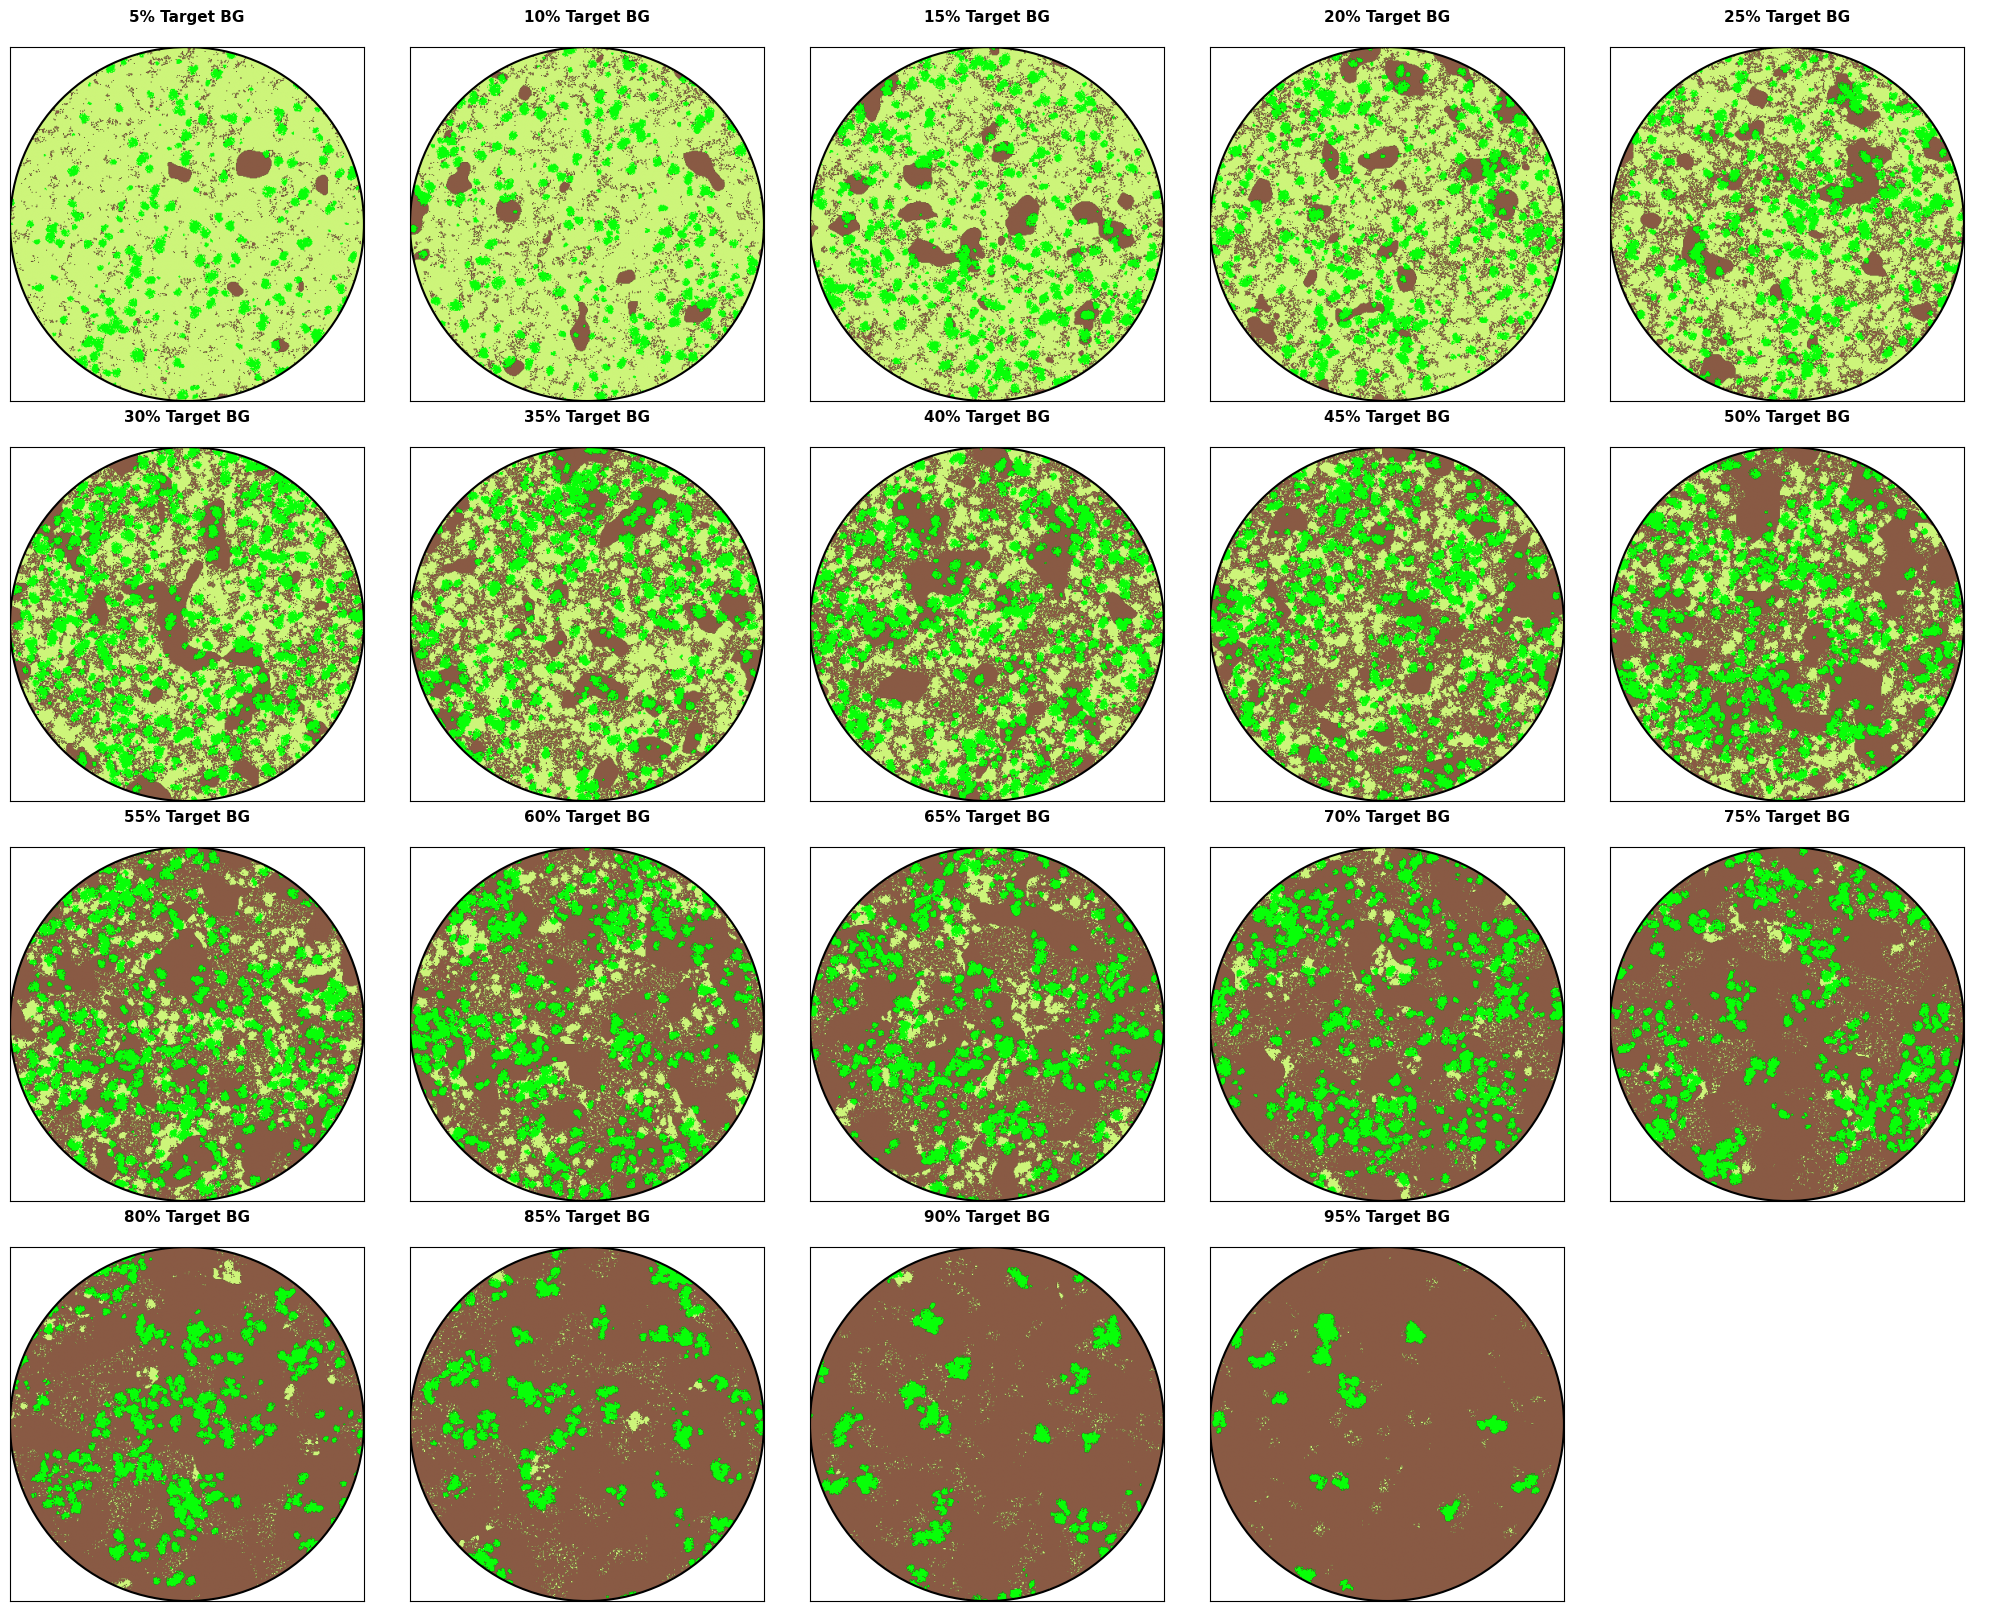

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# ====================================================================
# VISUALIZATION: 4x5 GRID (5% to 95% BG)
# ====================================================================
target_bgs_viz = np.arange(5, 100, 5)

fig, axes = plt.subplots(4, 5, figsize=(20, 16), constrained_layout=True)
axes = axes.flatten()

viz_cell_size = 0.25
plot_radius = 55
grid_size = int((plot_radius * 2) / viz_cell_size)

x = np.linspace(-plot_radius, plot_radius, grid_size)
y = np.linspace(-plot_radius, plot_radius, grid_size)
X, Y = np.meshgrid(x, y)
valid_mask = (X**2 + Y**2) <= plot_radius**2
total_valid_pixels = np.sum(valid_mask)

r_large_bnds = (0.3, 2.0)
r_small_bnds = (0.10, 0.30)

shadow_angle = np.radians(135)
shadow_dx = np.cos(shadow_angle)
shadow_dy = np.sin(shadow_angle)

for i, ax in enumerate(axes):
    if i >= len(target_bgs_viz):
        ax.axis('off')
        continue

    target_bg = target_bgs_viz[i]

    large_shrub_value = 1
    small_shrub_value = 2
    target_value = 3

    # Colormap
    cmap = mcolors.ListedColormap(['xkcd:fluorescent green', '#CDF57A', '#895A44'])
    norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

    # ==========================================
    # Z-INDEXED HYBRID LOGIC (EXPONENTIAL DECAY)
    # ==========================================
    organic_weight = 0.60
    organic_bg_pct = target_bg * organic_weight

    initial_veg_coverage = (100.0 - target_bg) / (100.0 - organic_bg_pct)
    base_lambda = -np.log(1 - initial_veg_coverage) if initial_veg_coverage < 0.99 else 5.0

    # Calculate how much extra boost we need at the absolute lowest BG
    boost_amount = max(0.0, 6.5 - base_lambda)

    # 1. PRESERVE ORIGINAL WOODY CURVE (Decays rapidly by ~12% BG)
    woody_decay = np.exp(-target_bg / 4.0)
    lambda_woody_base = base_lambda + (boost_amount * woody_decay)

    # 2. ENSURE ENOUGH PUNCHABLE COVER (Decays smoothly by ~40% BG)
    total_decay = np.exp(-target_bg / 12.0)
    lambda_total = base_lambda + (boost_amount * total_decay)

    alpha_large = 0.75

    # 3. Calculate Large (Woody)
    lambda_large = lambda_woody_base * alpha_large

    # 4. Calculate Small (Herbaceous)
    lambda_small = lambda_total - lambda_large

    mean_area_large = np.pi * ((r_large_bnds[0]**2 + r_large_bnds[0]*r_large_bnds[1] + r_large_bnds[1]**2) / 3.0)
    mean_area_small = np.pi * ((r_small_bnds[0]**2 + r_small_bnds[0]*r_small_bnds[1] + r_small_bnds[1]**2) / 3.0)

    plot_area = np.pi * (plot_radius**2)
    num_large = int(lambda_large * (plot_area / mean_area_large))
    num_small = int(lambda_small * (plot_area / mean_area_small))

    # Calculate retention probability here BEFORE drawing occurs
    if target_bg <= 50:
        prob_dark = np.interp(target_bg, [5, 50], [0.05, 0.45])
    else:
        prob_dark = np.interp(target_bg, [50, 100], [0.45, 1.0])

    # ==========================================
    # DECOUPLED SPATIAL PROCESSES
    # ==========================================
    cluster_spread = np.interp(target_bg, [0, 100], [8.0, 1.0])

    # Use floats for smooth scaling to prevent integer step-function variance spikes
    shrubs_per_cluster_float = np.interp(target_bg, [0, 100], [2.0, 10.0])
    num_parents = max(1, int(num_large / shrubs_per_cluster_float)) if num_large > 0 else 0

    large_mask = np.zeros((grid_size, grid_size), dtype=bool)
    small_mask = np.zeros((grid_size, grid_size), dtype=bool)

    # 1. Large Shrubs: Dynamic Thomas Cluster
    if num_parents > 0:
        gen_radius = plot_radius + r_large_bnds[1] + cluster_spread
        r_parents = gen_radius * np.sqrt(np.random.uniform(0, 1, num_parents))
        theta_parents = np.random.uniform(0, 2 * np.pi, num_parents)
        px_arr = r_parents * np.cos(theta_parents)
        py_arr = r_parents * np.sin(theta_parents)

        # Determine which entire Thomas Clusters stay Woody vs turn Herbaceous
        is_woody_parent = np.random.rand(num_parents) <= prob_dark

        if num_large > 0:
            r_large_arr = np.random.uniform(r_large_bnds[0], r_large_bnds[1], num_large)
            for rad in r_large_arr:
                parent_idx = np.random.randint(0, num_parents)
                cx = np.random.normal(px_arr[parent_idx], cluster_spread)
                cy = np.random.normal(py_arr[parent_idx], cluster_spread)

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / viz_cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / viz_cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                dot_prod = (dx * shadow_dx + dy * shadow_dy) / (r_grid + 1e-5)
                shadow_intensity = np.clip(dot_prod, 0, 1)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(3, 6)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.4, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                norm_dist = np.clip((r_grid - r_core) / rad, 0, 1)
                porosity_chance = 0.10 + 0.80 * shadow_intensity * (norm_dist ** 1.5)
                fringe_keep_mask = np.random.rand(*dx.shape) > porosity_chance
                lobe_mask &= fringe_keep_mask

                # Route the generated shrub into the correct layer based on its parent's coin flip
                if is_woody_parent[parent_idx]:
                    large_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)
                else:
                    small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    # 2. Small Shrubs: Thomas Cluster
    if num_small > 0:
        shrubs_per_cluster_small_float = np.interp(target_bg, [0, 100], [5.0, 20.0])
        num_parents_small = max(1, int(num_small / shrubs_per_cluster_small_float))
        cluster_spread_small = cluster_spread * 0.80

        if num_parents_small > 0:
            gen_radius_small = plot_radius + r_small_bnds[1] + cluster_spread_small
            r_parents_s = gen_radius_small * np.sqrt(np.random.uniform(0, 1, num_parents_small))
            theta_parents_s = np.random.uniform(0, 2 * np.pi, num_parents_small)
            px_arr_s = r_parents_s * np.cos(theta_parents_s)
            py_arr_s = r_parents_s * np.sin(theta_parents_s)

            r_small_arr = np.random.uniform(r_small_bnds[0], r_small_bnds[1], num_small)
            for rad in r_small_arr:
                parent_idx = np.random.randint(0, num_parents_small)
                cx = np.random.normal(px_arr_s[parent_idx], cluster_spread_small)
                cy = np.random.normal(py_arr_s[parent_idx], cluster_spread_small)

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / viz_cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / viz_cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(2, 5)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.3, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    # ==========================================
    # ASSEMBLE GRID & FRACTAL NOISE PUNCHING
    # ==========================================
    main_array = np.full((grid_size, grid_size), target_value, dtype=float)
    main_array[small_mask] = small_shrub_value
    main_array[large_mask] = large_shrub_value

    target_bare_pixels = int(total_valid_pixels * (target_bg / 100.0))
    current_bare_pixels = np.sum((main_array == target_value) & valid_mask)
    pixels_to_punch = target_bare_pixels - current_bare_pixels

    if pixels_to_punch > 0:
        punchable_mask = small_mask & ~large_mask & valid_mask
        punchable_count = np.sum(punchable_mask)

        if pixels_to_punch >= punchable_count:
            main_array[punchable_mask] = target_value
        else:
            raw_fine = np.random.rand(grid_size, grid_size)
            raw_coarse = np.random.rand(grid_size, grid_size)

            blurred_fine = gaussian_filter(raw_fine, sigma=(1.00 / viz_cell_size))
            blurred_coarse = gaussian_filter(raw_coarse, sigma=(3.00 / viz_cell_size))

            fractal_noise = (0.95 * blurred_coarse) + (0.05 * blurred_fine)

            punchable_noise = fractal_noise[punchable_mask]
            fraction_to_punch = pixels_to_punch / punchable_count
            threshold = np.percentile(punchable_noise, (1 - fraction_to_punch) * 100)

            hole_mask = punchable_mask & (fractal_noise >= threshold)
            main_array[hole_mask] = target_value

    main_array[~valid_mask] = np.nan

    # ==========================================
    # RENDER PLOT
    # ==========================================
    extent = [-plot_radius, plot_radius, -plot_radius, plot_radius]

    ax.imshow(main_array, cmap=cmap, norm=norm, extent=extent, origin='lower')

    ax.contour(main_array == target_value, levels=[0.5], colors='black',
               linewidths=0.15, alpha=0.7, extent=extent, origin='lower')

    ax.set_title(f'{target_bg}% Target BG\n', fontsize=11, weight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

    circle = plt.Circle((0, 0), plot_radius, color='black', fill=False, linewidth=1.5)
    ax.add_patch(circle)

# ==========================================
# EXPORT AND SHOW
# ==========================================
output_dir = '/content/drive/MyDrive/GEE_Downloads'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'bg_visualization_grid.svg')

fig.savefig(output_file, format='svg', bbox_inches='tight')
print(f"Figure successfully saved to: {output_file}")

plt.show()


### Big plots

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# ====================================================================
# VISUALIZATION: EXPORT INDIVIDUAL FIGURES
# ====================================================================
target_bgs_viz = np.arange(5, 100, 5)

viz_cell_size = 0.25
plot_radius = 55
grid_size = int((plot_radius * 2) / viz_cell_size)

x = np.linspace(-plot_radius, plot_radius, grid_size)
y = np.linspace(-plot_radius, plot_radius, grid_size)
X, Y = np.meshgrid(x, y)
valid_mask = (X**2 + Y**2) <= plot_radius**2
total_valid_pixels = np.count_nonzero(valid_mask)

r_large_bnds = (0.3, 2.0)
r_small_bnds = (0.10, 0.30)

shadow_angle = np.radians(135)
shadow_dx = np.cos(shadow_angle)
shadow_dy = np.sin(shadow_angle)

output_dir = '/content/drive/MyDrive/GEE_Downloads/Individual_Sims'
os.makedirs(output_dir, exist_ok=True)

for target_bg in target_bgs_viz:
    print(f"Generating and saving simulation for {target_bg}%...")

    # Create a single figure per iteration
    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

    large_shrub_value = 1
    small_shrub_value = 2
    target_value = 3

    cmap = mcolors.ListedColormap(['xkcd:fluorescent green', '#CDF57A', '#895A44'])
    norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

    # ==========================================
    # Z-INDEXED HYBRID LOGIC (EXPONENTIAL DECAY)
    # ==========================================
    organic_weight = 0.60
    organic_bg_pct = target_bg * organic_weight

    initial_veg_coverage = (100.0 - target_bg) / (100.0 - organic_bg_pct)
    base_lambda = -np.log(1 - initial_veg_coverage) if initial_veg_coverage < 0.99 else 5.0

    boost_amount = max(0.0, 6.5 - base_lambda)

    woody_decay = np.exp(-target_bg / 4.0)
    lambda_woody_base = base_lambda + (boost_amount * woody_decay)

    total_decay = np.exp(-target_bg / 12.0)
    lambda_total = base_lambda + (boost_amount * total_decay)

    alpha_large = 0.75
    lambda_large = lambda_woody_base * alpha_large
    lambda_small = lambda_total - lambda_large

    mean_area_large = np.pi * ((r_large_bnds[0]**2 + r_large_bnds[0]*r_large_bnds[1] + r_large_bnds[1]**2) / 3.0)
    mean_area_small = np.pi * ((r_small_bnds[0]**2 + r_small_bnds[0]*r_small_bnds[1] + r_small_bnds[1]**2) / 3.0)

    plot_area = np.pi * (plot_radius**2)
    num_large = int(lambda_large * (plot_area / mean_area_large))
    num_small = int(lambda_small * (plot_area / mean_area_small))

    if target_bg <= 50:
        prob_dark = np.interp(target_bg, [5, 50], [0.05, 0.45])
    else:
        prob_dark = np.interp(target_bg, [50, 100], [0.45, 1.0])

    # ==========================================
    # DECOUPLED SPATIAL PROCESSES
    # ==========================================
    cluster_spread = np.interp(target_bg, [0, 100], [8.0, 1.0])

    shrubs_per_cluster_float = np.interp(target_bg, [0, 100], [2.0, 10.0])
    num_parents = max(1, int(num_large / shrubs_per_cluster_float)) if num_large > 0 else 0

    large_mask = np.zeros((grid_size, grid_size), dtype=bool)
    small_mask = np.zeros((grid_size, grid_size), dtype=bool)

    if num_parents > 0:
        gen_radius = plot_radius + r_large_bnds[1] + cluster_spread
        r_parents = gen_radius * np.sqrt(np.random.uniform(0, 1, num_parents))
        theta_parents = np.random.uniform(0, 2 * np.pi, num_parents)
        px_arr = r_parents * np.cos(theta_parents)
        py_arr = r_parents * np.sin(theta_parents)
        is_woody_parent = np.random.rand(num_parents) <= prob_dark

        if num_large > 0:
            r_large_arr = np.random.uniform(r_large_bnds[0], r_large_bnds[1], num_large)
            for rad in r_large_arr:
                parent_idx = np.random.randint(0, num_parents)
                cx = np.random.normal(px_arr[parent_idx], cluster_spread)
                cy = np.random.normal(py_arr[parent_idx], cluster_spread)

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / viz_cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / viz_cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                dot_prod = (dx * shadow_dx + dy * shadow_dy) / (r_grid + 1e-5)
                shadow_intensity = np.clip(dot_prod, 0, 1)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(3, 6)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.4, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                norm_dist = np.clip((r_grid - r_core) / rad, 0, 1)
                porosity_chance = 0.10 + 0.80 * shadow_intensity * (norm_dist ** 1.5)
                fringe_keep_mask = np.random.rand(*dx.shape) > porosity_chance
                lobe_mask &= fringe_keep_mask

                if is_woody_parent[parent_idx]:
                    large_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)
                else:
                    small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    if num_small > 0:
        shrubs_per_cluster_small_float = np.interp(target_bg, [0, 100], [5.0, 20.0])
        num_parents_small = max(1, int(num_small / shrubs_per_cluster_small_float))
        cluster_spread_small = cluster_spread * 0.80

        if num_parents_small > 0:
            gen_radius_small = plot_radius + r_small_bnds[1] + cluster_spread_small
            r_parents_s = gen_radius_small * np.sqrt(np.random.uniform(0, 1, num_parents_small))
            theta_parents_s = np.random.uniform(0, 2 * np.pi, num_parents_small)
            px_arr_s = r_parents_s * np.cos(theta_parents_s)
            py_arr_s = r_parents_s * np.sin(theta_parents_s)

            r_small_arr = np.random.uniform(r_small_bnds[0], r_small_bnds[1], num_small)
            for rad in r_small_arr:
                parent_idx = np.random.randint(0, num_parents_small)
                cx = np.random.normal(px_arr_s[parent_idx], cluster_spread_small)
                cy = np.random.normal(py_arr_s[parent_idx], cluster_spread_small)

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / viz_cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / viz_cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(2, 5)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.3, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    # ==========================================
    # ASSEMBLE GRID & FRACTAL NOISE PUNCHING
    # ==========================================
    main_array = np.full((grid_size, grid_size), target_value, dtype=float)
    main_array[small_mask] = small_shrub_value
    main_array[large_mask] = large_shrub_value

    target_bare_pixels = int(total_valid_pixels * (target_bg / 100.0))
    current_bare_pixels = np.count_nonzero((main_array == target_value) & valid_mask)
    pixels_to_punch = target_bare_pixels - current_bare_pixels

    if pixels_to_punch > 0:
        punchable_mask = small_mask & ~large_mask & valid_mask
        punchable_count = np.count_nonzero(punchable_mask)

        if pixels_to_punch >= punchable_count:
            main_array[punchable_mask] = target_value
        else:
            raw_fine = np.random.rand(grid_size, grid_size)
            raw_coarse = np.random.rand(grid_size, grid_size)

            blurred_fine = gaussian_filter(raw_fine, sigma=(1.00 / viz_cell_size))
            blurred_coarse = gaussian_filter(raw_coarse, sigma=(3.00 / viz_cell_size))

            fractal_noise = (0.95 * blurred_coarse) + (0.05 * blurred_fine)

            punchable_noise = fractal_noise[punchable_mask]
            fraction_to_punch = pixels_to_punch / punchable_count
            threshold = np.percentile(punchable_noise, (1 - fraction_to_punch) * 100)

            hole_mask = punchable_mask & (fractal_noise >= threshold)
            main_array[hole_mask] = target_value

    main_array[~valid_mask] = np.nan

    # ==========================================
    # RENDER PLOT
    # ==========================================
    extent = [-plot_radius, plot_radius, -plot_radius, plot_radius]

    ax.imshow(main_array, cmap=cmap, norm=norm, extent=extent, origin='lower')
    ax.contour(main_array == target_value, levels=[0.5], colors='black',
               linewidths=0.25, alpha=0.7, extent=extent, origin='lower')

    ax.set_title(f'{target_bg}% Target BG', fontsize=18, weight='bold', pad=10)
    ax.set_xticks([])
    ax.set_yticks([])

    circle = plt.Circle((0, 0), plot_radius, color='black', fill=False, linewidth=2.0)
    ax.add_patch(circle)

    # Save immediately to prevent memory ballooning
    output_file = os.path.join(output_dir, f'bg_visualization_{target_bg:02d}.svg')
    fig.savefig(output_file, format='svg', bbox_inches='tight')

    # Close the figure to free up RAM
    plt.close(fig)

print("\nAll individual figures successfully exported!")

Generating and saving simulation for 5%...
Generating and saving simulation for 10%...
Generating and saving simulation for 15%...
Generating and saving simulation for 20%...
Generating and saving simulation for 25%...
Generating and saving simulation for 30%...
Generating and saving simulation for 35%...
Generating and saving simulation for 40%...
Generating and saving simulation for 45%...
Generating and saving simulation for 50%...
Generating and saving simulation for 55%...
Generating and saving simulation for 60%...
Generating and saving simulation for 65%...
Generating and saving simulation for 70%...
Generating and saving simulation for 75%...
Generating and saving simulation for 80%...
Generating and saving simulation for 85%...
Generating and saving simulation for 90%...
Generating and saving simulation for 95%...

All individual figures successfully exported!


### Big 2x3

Starting 2x3 Grid Generation and Consistency Check...
--------------------------------------------------
Target BG: 10% | Actual Rendered BG: 10.00%
Target BG: 25% | Actual Rendered BG: 25.00%
Target BG: 40% | Actual Rendered BG: 40.00%
Target BG: 55% | Actual Rendered BG: 55.00%
Target BG: 70% | Actual Rendered BG: 70.00%
Target BG: 90% | Actual Rendered BG: 90.00%
--------------------------------------------------
Figure successfully saved to: /content/drive/MyDrive/GEE_Downloads/bg_visualization_2x3_grid.svg


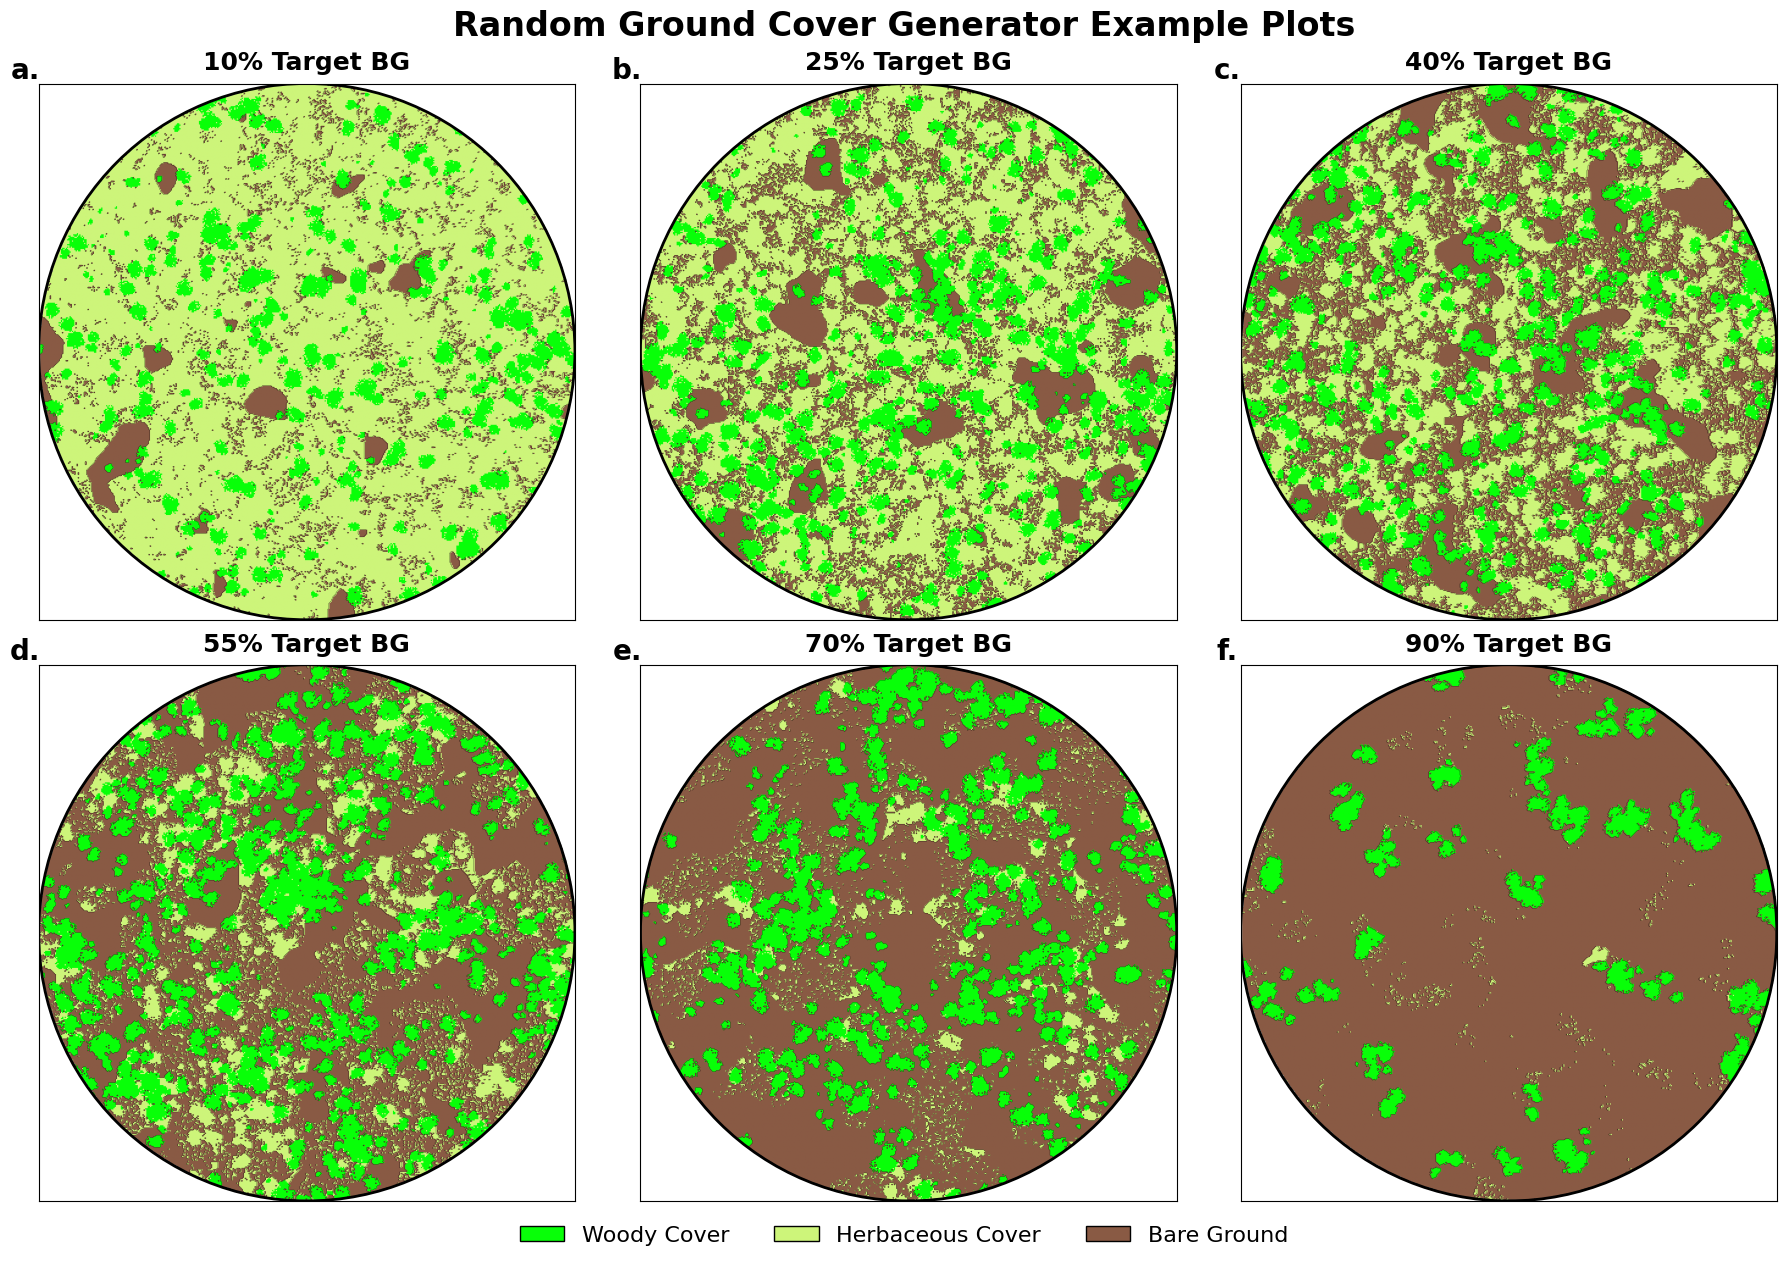

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter

# ====================================================================
# VISUALIZATION: 2x3 GRID (PUBLICATION READY)
# ====================================================================
# Select exactly 6 target BGRs for your 2x3 grid
target_bgs_viz = [10, 25, 40, 55, 70, 90]

fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)
fig.suptitle("Random Ground Cover Generator Example Plots", fontsize=24, weight='bold')
axes = axes.flatten()

viz_cell_size = 0.25
plot_radius = 55
grid_size = int((plot_radius * 2) / viz_cell_size)

x = np.linspace(-plot_radius, plot_radius, grid_size)
y = np.linspace(-plot_radius, plot_radius, grid_size)
X, Y = np.meshgrid(x, y)
valid_mask = (X**2 + Y**2) <= plot_radius**2
total_valid_pixels = np.count_nonzero(valid_mask)

r_large_bnds = (0.3, 2.0)
r_small_bnds = (0.10, 0.30)

shadow_angle = np.radians(135)
shadow_dx = np.cos(shadow_angle)
shadow_dy = np.sin(shadow_angle)

print("Starting 2x3 Grid Generation and Consistency Check...")
print("-" * 50)

for i, ax in enumerate(axes):
    if i >= len(target_bgs_viz):
        ax.axis('off')
        continue

    target_bg = target_bgs_viz[i]

    large_shrub_value = 1
    small_shrub_value = 2
    target_value = 3

    # Colormap
    cmap = mcolors.ListedColormap(['xkcd:fluorescent green', '#CDF57A', '#895A44'])
    norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

    # ==========================================
    # Z-INDEXED HYBRID LOGIC (EXPONENTIAL DECAY)
    # ==========================================
    organic_weight = 0.60
    organic_bg_pct = target_bg * organic_weight

    initial_veg_coverage = (100.0 - target_bg) / (100.0 - organic_bg_pct)
    base_lambda = -np.log(1 - initial_veg_coverage) if initial_veg_coverage < 0.99 else 5.0

    # Calculate how much extra boost we need at the absolute lowest BG
    boost_amount = max(0.0, 6.5 - base_lambda)

    # 1. PRESERVE ORIGINAL WOODY CURVE (Decays rapidly by ~12% BG)
    woody_decay = np.exp(-target_bg / 4.0)
    lambda_woody_base = base_lambda + (boost_amount * woody_decay)

    # 2. ENSURE ENOUGH PUNCHABLE COVER (Decays smoothly by ~40% BG)
    total_decay = np.exp(-target_bg / 12.0)
    lambda_total = base_lambda + (boost_amount * total_decay)

    alpha_large = 0.75

    # 3. Calculate Large (Woody)
    lambda_large = lambda_woody_base * alpha_large

    # 4. Calculate Small (Herbaceous)
    lambda_small = lambda_total - lambda_large

    mean_area_large = np.pi * ((r_large_bnds[0]**2 + r_large_bnds[0]*r_large_bnds[1] + r_large_bnds[1]**2) / 3.0)
    mean_area_small = np.pi * ((r_small_bnds[0]**2 + r_small_bnds[0]*r_small_bnds[1] + r_small_bnds[1]**2) / 3.0)

    plot_area = np.pi * (plot_radius**2)
    num_large = int(lambda_large * (plot_area / mean_area_large))
    num_small = int(lambda_small * (plot_area / mean_area_small))

    # Calculate retention probability here BEFORE drawing occurs
    if target_bg <= 50:
        prob_dark = np.interp(target_bg, [5, 50], [0.05, 0.45])
    else:
        prob_dark = np.interp(target_bg, [50, 100], [0.45, 1.0])

    # ==========================================
    # DECOUPLED SPATIAL PROCESSES
    # ==========================================
    cluster_spread = np.interp(target_bg, [0, 100], [8.0, 1.0])

    # Use floats for smooth scaling to prevent integer step-function variance spikes
    shrubs_per_cluster_float = np.interp(target_bg, [0, 100], [2.0, 10.0])
    num_parents = max(1, int(num_large / shrubs_per_cluster_float)) if num_large > 0 else 0

    large_mask = np.zeros((grid_size, grid_size), dtype=bool)
    small_mask = np.zeros((grid_size, grid_size), dtype=bool)

    # 1. Large Shrubs: Dynamic Thomas Cluster
    if num_parents > 0:
        gen_radius = plot_radius + r_large_bnds[1] + cluster_spread
        r_parents = gen_radius * np.sqrt(np.random.uniform(0, 1, num_parents))
        theta_parents = np.random.uniform(0, 2 * np.pi, num_parents)
        px_arr = r_parents * np.cos(theta_parents)
        py_arr = r_parents * np.sin(theta_parents)

        # Determine which entire Thomas Clusters stay Woody vs turn Herbaceous
        is_woody_parent = np.random.rand(num_parents) <= prob_dark

        if num_large > 0:
            r_large_arr = np.random.uniform(r_large_bnds[0], r_large_bnds[1], num_large)
            for rad in r_large_arr:
                parent_idx = np.random.randint(0, num_parents)
                cx = np.random.normal(px_arr[parent_idx], cluster_spread)
                cy = np.random.normal(py_arr[parent_idx], cluster_spread)

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / viz_cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / viz_cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                dot_prod = (dx * shadow_dx + dy * shadow_dy) / (r_grid + 1e-5)
                shadow_intensity = np.clip(dot_prod, 0, 1)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(3, 6)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.4, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                norm_dist = np.clip((r_grid - r_core) / rad, 0, 1)
                porosity_chance = 0.10 + 0.80 * shadow_intensity * (norm_dist ** 1.5)
                fringe_keep_mask = np.random.rand(*dx.shape) > porosity_chance
                lobe_mask &= fringe_keep_mask

                # Route the generated shrub into the correct layer based on its parent's coin flip
                if is_woody_parent[parent_idx]:
                    large_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)
                else:
                    small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    # 2. Small Shrubs: Thomas Cluster
    if num_small > 0:
        shrubs_per_cluster_small_float = np.interp(target_bg, [0, 100], [5.0, 20.0])
        num_parents_small = max(1, int(num_small / shrubs_per_cluster_small_float))
        cluster_spread_small = cluster_spread * 0.80

        if num_parents_small > 0:
            gen_radius_small = plot_radius + r_small_bnds[1] + cluster_spread_small
            r_parents_s = gen_radius_small * np.sqrt(np.random.uniform(0, 1, num_parents_small))
            theta_parents_s = np.random.uniform(0, 2 * np.pi, num_parents_small)
            px_arr_s = r_parents_s * np.cos(theta_parents_s)
            py_arr_s = r_parents_s * np.sin(theta_parents_s)

            r_small_arr = np.random.uniform(r_small_bnds[0], r_small_bnds[1], num_small)
            for rad in r_small_arr:
                parent_idx = np.random.randint(0, num_parents_small)
                cx = np.random.normal(px_arr_s[parent_idx], cluster_spread_small)
                cy = np.random.normal(py_arr_s[parent_idx], cluster_spread_small)

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / viz_cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / viz_cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / viz_cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(2, 5)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.3, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    # ==========================================
    # ASSEMBLE GRID & FRACTAL NOISE PUNCHING
    # ==========================================
    main_array = np.full((grid_size, grid_size), target_value, dtype=float)
    main_array[small_mask] = small_shrub_value
    main_array[large_mask] = large_shrub_value

    target_bare_pixels = int(total_valid_pixels * (target_bg / 100.0))
    current_bare_pixels = np.count_nonzero((main_array == target_value) & valid_mask)
    pixels_to_punch = target_bare_pixels - current_bare_pixels

    if pixels_to_punch > 0:
        punchable_mask = small_mask & ~large_mask & valid_mask
        punchable_count = np.count_nonzero(punchable_mask)

        if pixels_to_punch >= punchable_count:
            main_array[punchable_mask] = target_value
        else:
            raw_fine = np.random.rand(grid_size, grid_size)
            raw_coarse = np.random.rand(grid_size, grid_size)

            blurred_fine = gaussian_filter(raw_fine, sigma=(1.00 / viz_cell_size))
            blurred_coarse = gaussian_filter(raw_coarse, sigma=(3.00 / viz_cell_size))

            fractal_noise = (0.95 * blurred_coarse) + (0.05 * blurred_fine)

            punchable_noise = fractal_noise[punchable_mask]
            fraction_to_punch = pixels_to_punch / punchable_count
            threshold = np.percentile(punchable_noise, (1 - fraction_to_punch) * 100)

            hole_mask = punchable_mask & (fractal_noise >= threshold)
            main_array[hole_mask] = target_value

    # --- CONSISTENCY CHECK ---
    is_bare = (main_array == target_value)
    actual_bare_pixels = np.count_nonzero(is_bare & valid_mask)
    actual_bg_pct = (actual_bare_pixels / total_valid_pixels) * 100
    print(f"Target BG: {target_bg:2d}% | Actual Rendered BG: {actual_bg_pct:.2f}%")

    main_array[~valid_mask] = np.nan

    # ==========================================
    # RENDER PLOT
    # ==========================================
    extent = [-plot_radius, plot_radius, -plot_radius, plot_radius]

    ax.imshow(main_array, cmap=cmap, norm=norm, extent=extent, origin='lower')
    ax.contour(main_array == target_value, levels=[0.5], colors='black',
               linewidths=0.25, alpha=0.7, extent=extent, origin='lower')

    ax.set_title(f'{target_bg}% Target BG', fontsize=18, weight='bold', pad=10)
    ax.set_xticks([])
    ax.set_yticks([])

    # Add the circular boundary
    circle = plt.Circle((0, 0), plot_radius, color='black', fill=False, linewidth=2.0)
    ax.add_patch(circle)

    # Add Publication Panel Labels a., b., c., etc.
    panel_label = chr(97 + i) # 97 is ASCII for 'a'
    ax.text(-plot_radius * 1.05, plot_radius * 1.05, f'{panel_label}.',
            fontsize=20, weight='bold', va='center', ha='center')


# ==========================================
# GLOBAL LEGEND & EXPORT
# ==========================================
print("-" * 50)

# Create custom patches for the legend
legend_elements = [
    mpatches.Patch(facecolor='xkcd:fluorescent green', edgecolor='black', label='Woody Cover'),
    mpatches.Patch(facecolor='#CDF57A', edgecolor='black', label='Herbaceous Cover'),
    mpatches.Patch(facecolor='#895A44', edgecolor='black', label='Bare Ground')
]

# Add the legend to the bottom of the entire figure
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=16,
           bbox_to_anchor=(0.5, -0.05), frameon=False)

output_dir = '/content/drive/MyDrive/GEE_Downloads'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'bg_visualization_2x3_grid.svg')

# Save with a high DPI to ensure publication quality
fig.savefig(output_file, format='svg', dpi=600, bbox_inches='tight')
print(f"Figure successfully saved to: {output_file}")
plt.show()
